# Create Boxplots Showing the Distribution of Generation by Month


In [1]:
# Start by importing the packages we need:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Suppress Future Warnings


In [2]:
# Suppress future warnings:
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)


## Set the Directory Structure

In [3]:
# Set the data input and output directories:
hw_cs_data_dir =  '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/data/thermal_events_data/'
integrated_time_series_data_input_dir = '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/data/integrated_time_series/'
image_output_dir =  '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/figures/regional_results/'


## Plot the Generation Mix by Month


In [11]:
def plot_generation_mix(region: str, hw_cs_data_dir: str, integrated_time_series_data_input_dir: str, image_output_dir: str, image_resolution: int, save_images=False):

    # Subset to just the data for region you want to use:
    if region == 'CA':
       region_name = 'California'
    if region == 'GB':
       region_name = 'Great Basin'
    if region == 'PNW':
       region_name = 'Pacific Northwest'    
    if region == 'RM':
       region_name = 'Rocky Mountains'
    if region == 'SW':
       region_name = 'Southwest'
        
    # Read in the heat wave event library and subset to just the region being plotted:
    hw_df = pd.read_csv((hw_cs_data_dir + 'hw_library_expanded.csv'))
    cs_df = pd.read_csv((hw_cs_data_dir + 'cs_library_expanded.csv'))
    hw_df = hw_df[(hw_df['Region'] == region)].copy()
    cs_df = cs_df[(cs_df['Region'] == region)].copy()

    # Read in the integrated time series:
    gen_df = pd.read_csv((integrated_time_series_data_input_dir + region + '_Integrated_Time_Series_1982_to_2019.csv'))

    # Extract the month and date for grouping:
    gen_df['Time_UTC'] = pd.to_datetime(gen_df['Time_UTC'])
    gen_df['Month'] = gen_df['Time_UTC'].dt.month
    gen_df['Date'] = gen_df['Time_UTC'].dt.date
    gen_df['Date'] = pd.to_datetime(gen_df['Date'])

    # Calculate the total generation across all types and for renewable vs non-renewable:
    gen_df['Total'] = gen_df['Coal'] + gen_df['Gas'] + gen_df['Hydro'] + gen_df['Other'] + gen_df['Solar'] + gen_df['Wind']
    gen_df['Fossil'] = gen_df['Coal'] + gen_df['Gas']
    gen_df['Renewable'] = gen_df['Hydro'] + gen_df['Solar'] + gen_df['Wind'] + gen_df['Other']

    # Subset to just the days with valid generation data:
    gen_df = gen_df.loc[(gen_df['Total'] >= 0) & (gen_df['Region_Load'] >= 0)].copy()
    
    # Loop over rows in the heat wave event library and extract the time series for just the events:
    for row in range(len(hw_df)):
        # Extract the start and end dates for the event in that row:
        start_date = pd.to_datetime(hw_df['Start'].iloc[[row]].item())
        end_date = pd.to_datetime(hw_df['End'].iloc[[row]].item())

        # Subset to just the hours during that event:
        temp_df = gen_df[(gen_df['Date'] >= start_date) & (gen_df['Date'] <= end_date)]

        # Aggregate the output into a new dataframe:
        if row == 0:
           hw_gen_df = temp_df
        else:
           hw_gen_df = pd.concat([hw_gen_df, temp_df])

        # Clean up and move to the next row:
        del start_date, end_date, temp_df

    # Loop over rows in the cold snap event library and extract the time series for just the events:
    for row in range(len(cs_df)):
        # Extract the start and end dates for the event in that row:
        start_date = pd.to_datetime(cs_df['Start'].iloc[[row]].item())
        end_date = pd.to_datetime(cs_df['End'].iloc[[row]].item())

        # Subset to just the hours during that event:
        temp_df = gen_df[(gen_df['Date'] >= start_date) & (gen_df['Date'] <= end_date)]

        # Aggregate the output into a new dataframe:
        if row == 0:
           cs_gen_df = temp_df
        else:
           cs_gen_df = pd.concat([cs_gen_df, temp_df])

        # Clean up and move to the next row:
        del start_date, end_date, temp_df
        
    # Subset to just the daytime values for solar:
    day_gen_df = gen_df[gen_df['Solar'] != 0]
    day_hw_gen_df = hw_gen_df[hw_gen_df['Solar'] != 0]
    day_cs_gen_df = cs_gen_df[cs_gen_df['Solar'] != 0]
        
    # Make the plot:
    plt.figure(figsize=(30,35))
    plt.rcParams['font.size'] = 18
    plt.rcParams['axes.axisbelow'] = True
    
    ax1 = plt.subplot(711)
    plt.plot([np.nan,np.nan], color='b', linestyle='-', label='Cold Snap Days', linewidth=2)
    plt.plot([np.nan,np.nan], color='k', linestyle='-', label='All Days', linewidth=2)
    plt.plot([np.nan,np.nan], color='r', linestyle='-', label='Heat Wave Days', linewidth=2)
    for month in range(1,13):
        box1a = plt.boxplot(gen_df['Region_Load'].loc[(gen_df['Month']==month)], vert=True, positions=[month], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box1a[item], color='k', markeredgecolor='k', linewidth=2)
        box1b = plt.boxplot(hw_gen_df['Region_Load'].loc[(hw_gen_df['Month']==month)], vert=True, positions=[month+0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box1b[item], color='r', markeredgecolor='r', linewidth=2)   
        box1c = plt.boxplot(cs_gen_df['Region_Load'].loc[(cs_gen_df['Month']==month)], vert=True, positions=[month-0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box1c[item], color='b', markeredgecolor='b', linewidth=2)    
    plt.legend(loc='upper left', prop={'size': 12})
    plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['','','','','','','','','','','',''])
    plt.xlim([0.5, 12.5])
    plt.ylabel('Demand [MW]', fontsize=18)
    plt.title(('Total Demand in ' + region_name + ' Region'))
    plt.title('a)', loc='left', fontsize=16)

    ax2 = plt.subplot(712)
    for month in range(1,13):
        box2a = plt.boxplot(gen_df['Fossil'].loc[(gen_df['Month']==month)], vert=True, positions=[month], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box2a[item], color='k', markeredgecolor='k', linewidth=2)
        box2b = plt.boxplot(hw_gen_df['Fossil'].loc[(hw_gen_df['Month']==month)], vert=True, positions=[month+0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box2b[item], color='r', markeredgecolor='r', linewidth=2)
        box2c = plt.boxplot(cs_gen_df['Fossil'].loc[(cs_gen_df['Month']==month)], vert=True, positions=[month-0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box2c[item], color='b', markeredgecolor='b', linewidth=2)    
    plt.ylim(bottom=0)
    plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['','','','','','','','','','','',''])
    plt.xlim([0.5, 12.5])
    plt.ylabel('Generation [MW]', fontsize=18)
    plt.title(('Coal and Gas Generation'))
    plt.title('b)', loc='left', fontsize=16)

    ax3 = plt.subplot(713)
    for month in range(1,13):
        box3a = plt.boxplot(gen_df['Hydro'].loc[(gen_df['Month']==month)], vert=True, positions=[month], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box3a[item], color='k', markeredgecolor='k', linewidth=2)
        box3b = plt.boxplot(hw_gen_df['Hydro'].loc[(hw_gen_df['Month']==month)], vert=True, positions=[month+0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box3b[item], color='r', markeredgecolor='r', linewidth=2)
        box3c = plt.boxplot(cs_gen_df['Hydro'].loc[(cs_gen_df['Month']==month)], vert=True, positions=[month-0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box3c[item], color='b', markeredgecolor='b', linewidth=2)
    plt.ylim(bottom=0)
    plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['','','','','','','','','','','',''])
    plt.xlim([0.5, 12.5])
    plt.ylabel('Generation [MW]', fontsize=18)
    plt.title(('Hydropower Generation'))
    plt.title('c)', loc='left', fontsize=16)

    ax4 = plt.subplot(714)
    for month in range(1,13):
        box4a = plt.boxplot(gen_df['Wind'].loc[(gen_df['Month']==month)], vert=True, positions=[month], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box4a[item], color='k', markeredgecolor='k', linewidth=2)
        box4b = plt.boxplot(hw_gen_df['Wind'].loc[(hw_gen_df['Month']==month)], vert=True, positions=[month+0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box4b[item], color='r', markeredgecolor='r', linewidth=2)
        box4c = plt.boxplot(cs_gen_df['Wind'].loc[(cs_gen_df['Month']==month)], vert=True, positions=[month-0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box4c[item], color='b', markeredgecolor='b', linewidth=2)
    plt.ylim(bottom=0)
    plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['','','','','','','','','','','',''])
    plt.xlim([0.5, 12.5])    
    plt.ylabel('Generation [MW]', fontsize=18)
    plt.title(('Wind Generation'))
    plt.title('d)', loc='left', fontsize=16)
    
    ax5 = plt.subplot(715)
    for month in range(1,13):
        box5a = plt.boxplot(day_gen_df['Solar'].loc[(day_gen_df['Month']==month)], vert=True, positions=[month], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box5a[item], color='k', markeredgecolor='k', linewidth=2)
        box5b = plt.boxplot(day_hw_gen_df['Solar'].loc[(day_hw_gen_df['Month']==month)], vert=True, positions=[month+0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box5b[item], color='r', markeredgecolor='r', linewidth=2)
        box5c = plt.boxplot(day_cs_gen_df['Solar'].loc[(day_cs_gen_df['Month']==month)], vert=True, positions=[month-0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box5c[item], color='b', markeredgecolor='r', linewidth=2)    
    plt.ylim(bottom=0)
    plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['','','','','','','','','','','',''])
    plt.xlim([0.5, 12.5])    
    plt.ylabel('Generation [MW]', fontsize=18)
    plt.title(('Solar Generation (Daytime Values Only)'))
    plt.title('e)', loc='left', fontsize=16)

    ax6 = plt.subplot(716)
    for month in range(1,13):
        box6a = plt.boxplot(gen_df['Imports'].loc[(gen_df['Month']==month)], vert=True, positions=[month], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box6a[item], color='k', markeredgecolor='k', linewidth=2)
        box6b = plt.boxplot(hw_gen_df['Imports'].loc[(hw_gen_df['Month']==month)], vert=True, positions=[month+0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box6b[item], color='r', markeredgecolor='r', linewidth=2)
        box6c = plt.boxplot(cs_gen_df['Imports'].loc[(cs_gen_df['Month']==month)], vert=True, positions=[month-0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box6c[item], color='b', markeredgecolor='b', linewidth=2)
    #plt.ylim(bottom=0)
    plt.plot([0,13], [0,0],'gray', linewidth=2)    
    plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['','','','','','','','','','','',''])
    plt.xlim([0.5, 12.5])    
    plt.ylabel('Imports [MW]', fontsize=18)
    plt.title(('Imports From Other Regions'))
    plt.title('f)', loc='left', fontsize=16)

    ax7 = plt.subplot(717)
    for month in range(1,13):
        box6a = plt.boxplot(gen_df['Load_Shed'].loc[(gen_df['Month']==month)], vert=True, positions=[month], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box6a[item], color='k', markeredgecolor='k', linewidth=2)
        box6b = plt.boxplot(hw_gen_df['Load_Shed'].loc[(hw_gen_df['Month']==month)], vert=True, positions=[month+0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box6b[item], color='r', markeredgecolor='r', linewidth=2)
        box6c = plt.boxplot(cs_gen_df['Load_Shed'].loc[(cs_gen_df['Month']==month)], vert=True, positions=[month-0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box6c[item], color='b', markeredgecolor='b', linewidth=2)
    #plt.ylim(bottom=0)
    plt.plot([0,13], [0,0],'gray', linewidth=2)    
    plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.xlim([0.5, 12.5])    
    plt.ylabel('Load Shed [MW]', fontsize=18)
    plt.title(('Load Shedding'))
    plt.title('g)', loc='left', fontsize=16)

    # If the "save_images" flag is set to true then save the plot to a .png file:
    if save_images == True:
       plt.savefig(os.path.join(image_output_dir + region + '_Annual_Generation.png'), dpi=image_resolution, bbox_inches='tight')
       plt.close()

    return gen_df


,Time_UTC,T_Min,T_Min_Mean,T_Max,T_Max_Mean,WECC_Load,WECC_Load_Mean,Region_Load,Region_Load_Mean,Coal,...,Solar,Wind,Imports,LMP,Load_Shed,Month,Date,Total,Fossil,Renewable
0,1982-01-01 07:00:00,38.79,40.73,47.65,54.3,104643.47,101540.68,37206.93,36971.80,55.0,...,0.0,1384.4,13088.5,35.11,0.0,1,1982-01-01,20652.1,8045.3,12606.8
1,1982-01-01 08:00:00,38.79,40.73,47.65,54.3,106183.54,103522.33,35904.66,35799.50,55.0,...,0.0,1524.9,11971.2,33.65,0.0,1,1982-01-01,20746.4,8187.8,12558.6
2,1982-01-01 09:00:00,38.79,40.73,47.65,54.3,106220.97,103765.49,34442.30,34363.53,55.0,...,0.0,1232.8,12183.3,28.60,0.0,1,1982-01-01,19957.2,8961.9,10995.3
3,1982-01-01 10:00:00,38.79,40.73,47.65,54.3,105750.10,103605.41,33618.46,33550.47,55.0,...,0.0,1130.5,12775.0,17.87,0.0,1,1982-01-01,19972.1,8890.2,11081.9
4,1982-01-01 11:00:00,38.79,40.73,47.65,54.3,104363.26,102367.04,33322.82,33192.73,55.0,...,0.0,1318.2,12887.1,21.35,0.0,1,1982-01-01,19819.6,8706.6,11113.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332875,2020-01-01 02:00:00,43.30,40.73,56.15,54.3,114471.43,114139.87,48563.00,48302.37,55.0,...,0.0,2045.4,14537.0,31.83,0.0,1,2020-01-01,29489.7,13344.9,16144.8
332876,2020-01-01 03:00:00,43.30,40.73,56.15,54.3,111724.83,111375.06,46363.27,46118.89,55.0,...,0.0,1982.6,13857.6,31.73,0.0,1,2020-01-01,28455.2,12377.2,16078.0
332877,2020-01-01 04:00:00,43.30,40.73,56.15,54.3,106092.98,105638.14,41065.47,40831.08,55.0,...,0.0,1973.8,12883.2,35.10,0.0,1,2020-01-01,26327.6,11715.7,14611.9
332878,2020-01-01 05:00:00,43.30,40.73,56.15,54.3,104669.28,104173.57,39844.16,39626.47,55.0,...,0.0,2017.1,12948.3,36.25,0.0,1,2020-01-01,26109.4,11723.3,14386.1


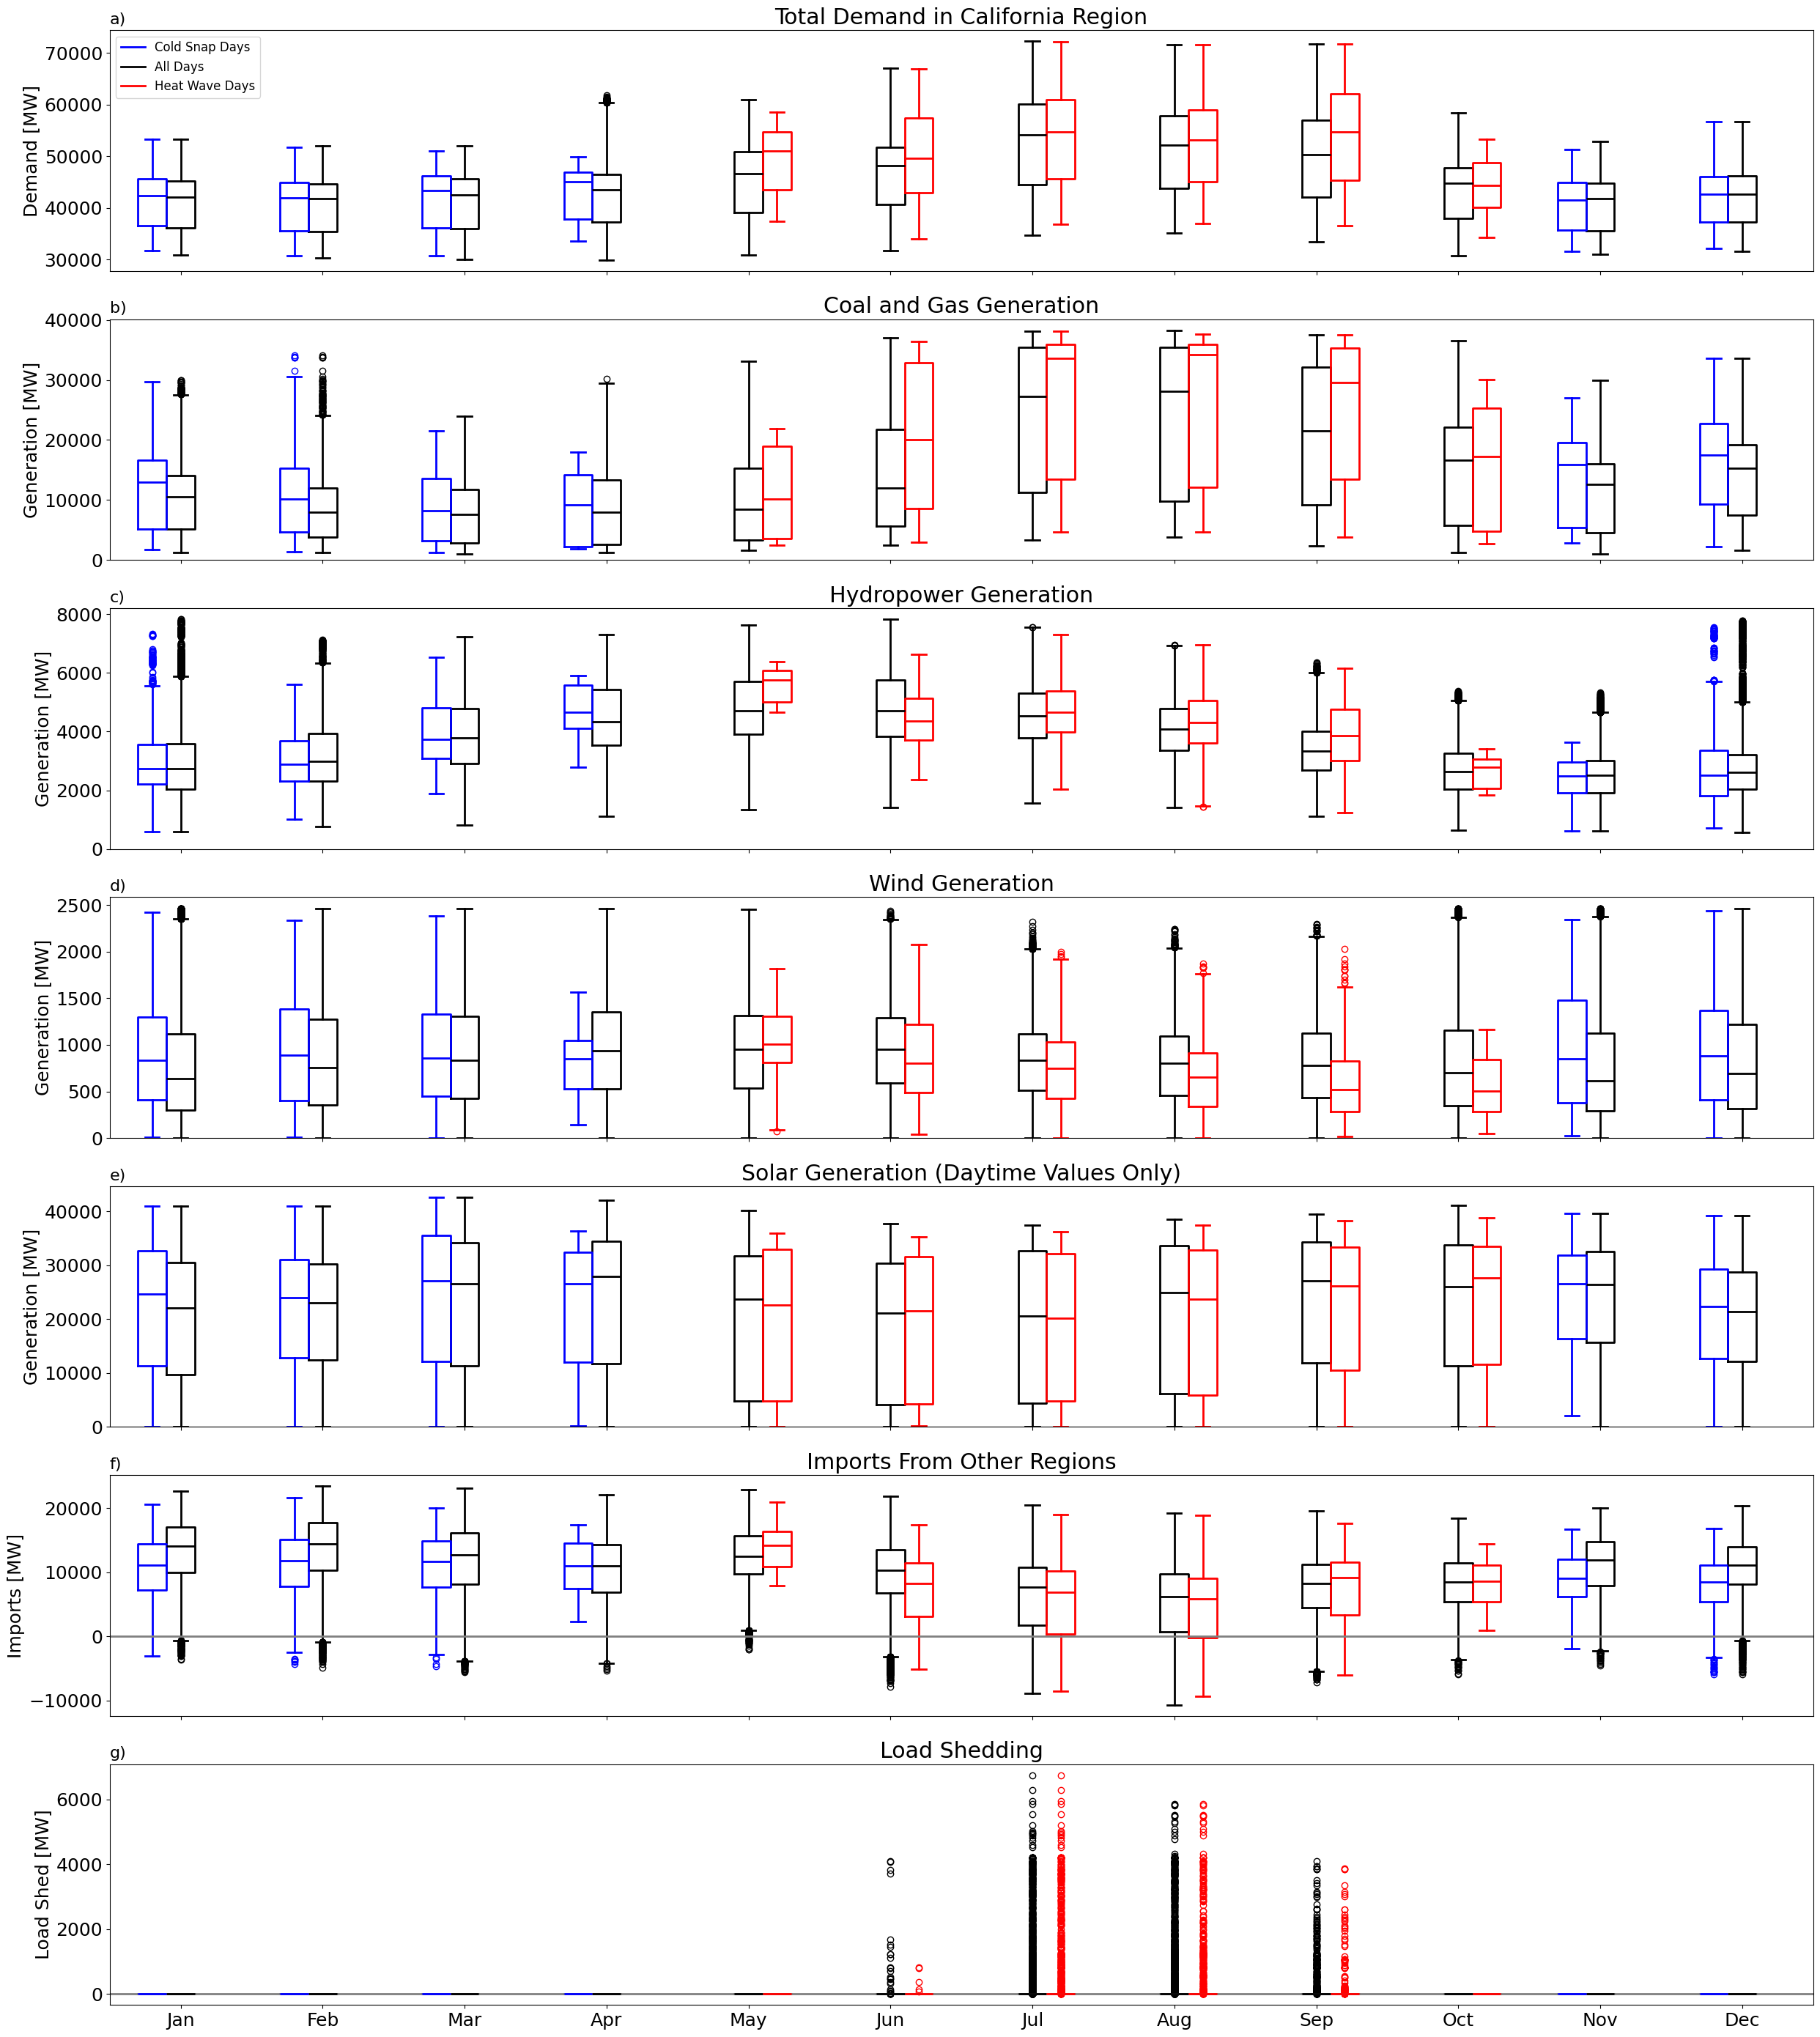

In [12]:
# Test the function:
output_df = plot_generation_mix(region = 'CA',
                                hw_cs_data_dir = hw_cs_data_dir,
                                integrated_time_series_data_input_dir = integrated_time_series_data_input_dir,
                                image_output_dir = image_output_dir, 
                                image_resolution = 150,
                                save_images = False)

output_df


In [13]:
# Loop over the NERC TPL-008-1 regions in the WECC and process the time series for each one:
for region in ['CA', 'GB', 'PNW', 'RM', 'SW']:
    plot_generation_mix(region = region,
                        hw_cs_data_dir = hw_cs_data_dir,
                        integrated_time_series_data_input_dir = integrated_time_series_data_input_dir,
                        image_output_dir = image_output_dir, 
                        image_resolution = 150,
                        save_images = True)
